In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv('medicore_raw.csv')
df.shape

(13453, 14)

In [ ]:
df.head()

,patient_id,visit_id,admission_date,department,region,city,patient_age,gender,length_of_stay,billing_amount,insurance_type,is_emergency,readmission,satisfaction_score
0,PAT101530,VIS106050,2024-10-24,orthopedics,West,Mumbai,80.0,Male,90.0,51208.29,Government Scheme,Scheduled,No,4.0
1,PAT102385,VIS109552,2024-07-17,Oncology,East,Guwahati,19.0,Female,3.0,73041.40,Self-Pay,Scheduled,No,4.0
2,PAT101791,VIS107125,2024-10-06,GENERAL MEDICINE,West,pune,24.0,Male,2.0,16271.49,Private Insurance,Scheduled,No,5.0
3,PAT100933,VIS103727,23/05/2024,Oncology,East,Kolkata,52.0,Male,NaN,74144.16,Corporate Insurance,Scheduled,No,NaN
4,PAT101832,VIS107290,2025-11-09,orthopedics,South,Kochi,39.0,Male,8.0,47344.12,Self-Pay,Scheduled,No,3.0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13453 entries, 0 to 13452
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          13453 non-null  str    
 1   visit_id            13453 non-null  str    
 2   admission_date      13453 non-null  str    
 3   department          13453 non-null  str    
 4   region              13453 non-null  str    
 5   city                13453 non-null  str    
 6   patient_age         13182 non-null  float64
 7   gender              13453 non-null  str    
 8   length_of_stay      13040 non-null  float64
 9   billing_amount      12917 non-null  float64
 10  insurance_type      13122 non-null  str    
 11  is_emergency        13453 non-null  str    
 12  readmission         13453 non-null  str    
 13  satisfaction_score  12642 non-null  float64
dtypes: float64(4), str(10)
memory usage: 1.4 MB


In [ ]:
df.isnull().sum()

patient_id              0
visit_id                0
admission_date          0
department              0
region                  0
city                    0
patient_age           271
gender                  0
length_of_stay        413
billing_amount        536
insurance_type        331
is_emergency            0
readmission             0
satisfaction_score    811
dtype: int64

In [ ]:
print(df['patient_age'].describe())
print(df['length_of_stay'].describe())

count    13182.000000
mean        44.948263
std         20.119661
min         -3.000000
25%         32.000000
50%         45.000000
75%         57.000000
max        180.000000
Name: patient_age, dtype: float64
count    13040.000000
mean         4.516718
std          9.300096
min        -45.000000
25%          2.000000
50%          3.000000
75%          5.000000
max        300.000000
Name: length_of_stay, dtype: float64


In [ ]:
df['patient_age'] = df['patient_age'].abs()
df['length_of_stay'] = df['length_of_stay'].abs()

In [ ]:
df['patient_age'] = df['patient_age'].fillna(df['patient_age'].median())
df['length_of_stay'] = df['length_of_stay'].fillna(df['length_of_stay'].median())
df['billing_amount'] = df['billing_amount'].fillna(df['billing_amount'].median())
df['insurance_type'] = df['insurance_type'].fillna(df['insurance_type'].mode()[0])
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].mode()[0])

df.isnull().sum()

patient_id            0
visit_id              0
admission_date        0
department            0
region                0
city                  0
patient_age           0
gender                0
length_of_stay        0
billing_amount        0
insurance_type        0
is_emergency          0
readmission           0
satisfaction_score    0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(1441)

In [ ]:
df = df.drop_duplicates()
df.shape

(12012, 14)

In [ ]:
df['department'] = df['department'].str.strip().str.title()
df['city'] = df['city'].str.strip().str.title()

df['department'].unique()

<StringArray>
[     'Orthopedics',         'Oncology', 'General Medicine',
        'Emergency',       'Pediatrics',       'Cardiology']
Length: 6, dtype: str

In [ ]:
def parse_date(x):
    for fmt in ('%Y-%m-%d', '%d/%m/%Y'):
        try:
            return pd.to_datetime(x, format=fmt)
        except:
            continue
    return pd.NaT

df['admission_date'] = df['admission_date'].apply(parse_date)
df['admission_date'].head()

0   2024-10-24
1   2024-07-17
2   2024-10-06
3   2024-05-23
4   2025-11-09
Name: admission_date, dtype: datetime64[us]

Outlier Detection

**patient_age** - the distribution is close to normal (aside from a few impossible values like 130, 140, 180), so the Z-score method is used.

In [ ]:
z_scores = np.abs(stats.zscore(df['patient_age']))
age_outliers = df[z_scores > 3]
print(age_outliers[['patient_age']])

       patient_age
146          180.0
166          140.0
191          130.0
224          140.0
337          130.0
...            ...
12788        130.0
12914        130.0
12931        140.0
13204        140.0
13284        180.0

[85 rows x 1 columns]


In [ ]:
df = df[z_scores <= 3]
df.shape

(11927, 14)

**length_of_stay** - this column is heavily right-skewed, so the IQR method is used.

In [ ]:
Q1 = df['length_of_stay'].quantile(0.25)
Q3 = df['length_of_stay'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

los_outliers = df[(df['length_of_stay'] < lower) | (df['length_of_stay'] > upper)]
print('Lower bound:', lower, 'Upper bound:', upper)
print('Number of outliers:', los_outliers.shape[0])

Lower bound: -2.5 Upper bound: 9.5
Number of outliers: 884


In [ ]:
df = df[(df['length_of_stay'] >= lower) & (df['length_of_stay'] <= upper)]
df.shape

(11043, 14)

**billing_amount** - this column is also heavily right-skewed, so the IQR method is used.

In [ ]:
Q1 = df['billing_amount'].quantile(0.25)
Q3 = df['billing_amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

bill_outliers = df[(df['billing_amount'] < lower) | (df['billing_amount'] > upper)]
print('Lower bound:', lower, 'Upper bound:', upper)
print('Number of outliers:', bill_outliers.shape[0])

Lower bound: -33191.02999999999 Upper bound: 96781.48999999999
Number of outliers: 171


In [ ]:
df = df[(df['billing_amount'] >= lower) & (df['billing_amount'] <= upper)]
df.shape

(10872, 14)

**satisfaction_score** - this is a fixed rating scale from 1 to 5, so every value in that range is valid and not an outlier.

In [ ]:
print(df['satisfaction_score'].min(), df['satisfaction_score'].max())
print("No outliers found in this column.")

1.0 5.0
No outliers found in this column.


In [ ]:
df.to_csv('Medicore_Cleaned_Data.csv', index=False)
df.shape

(10872, 14)

In [ ]:
bins = [0, 18, 35, 50, 65, 120]
labels = ['0-18', '19-35', '36-50', '51-65', '66+']
df['age_group'] = pd.cut(df['patient_age'], bins=bins, labels=labels, include_lowest=True)
df[['patient_age', 'age_group']].head()

,patient_age,age_group
1,19.0,19-35
2,24.0,19-35
3,52.0,51-65
4,39.0,36-50
5,56.0,51-65


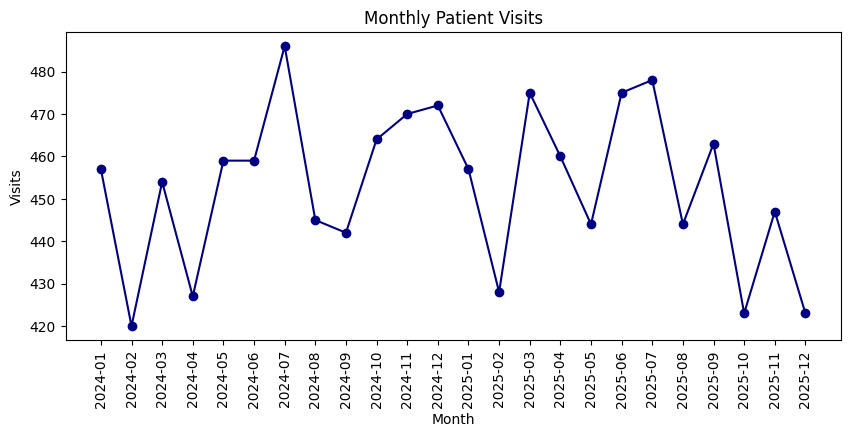

In [ ]:
#1.
df['month'] = df['admission_date'].dt.to_period('M').astype(str)
monthly = df.groupby('month').agg(visits=('visit_id', 'count'), revenue=('billing_amount', 'sum')).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(monthly['month'], monthly['visits'], color='navy', marker='o')
ax1.set_xlabel('Month')
ax1.set_ylabel('Visits')
ax1.set_title('Monthly Patient Visits')
plt.xticks(rotation=90)
plt.show()

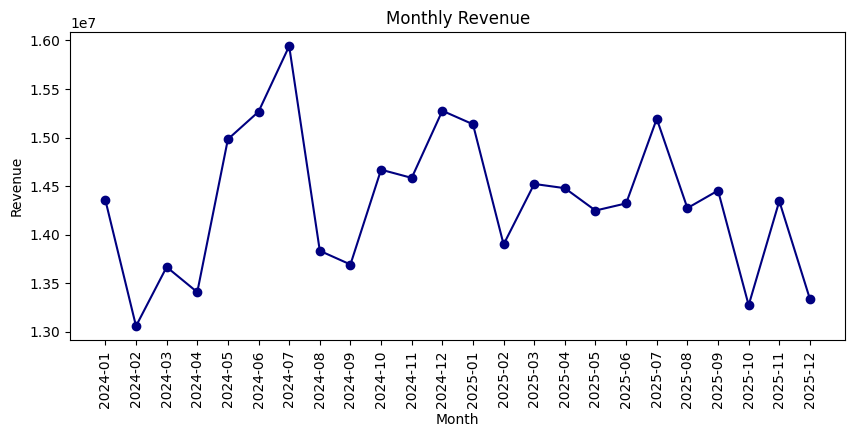

In [ ]:
#1.
fig, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(monthly['month'], monthly['revenue'], color='navy', marker='o')
ax2.set_xlabel('Month')
ax2.set_ylabel('Revenue')
ax2.set_title('Monthly Revenue')
plt.xticks(rotation=90)
plt.show()

Patient volume and revenue stay fairly steady month-over-month, without a strong upward or downward trend across the two years.

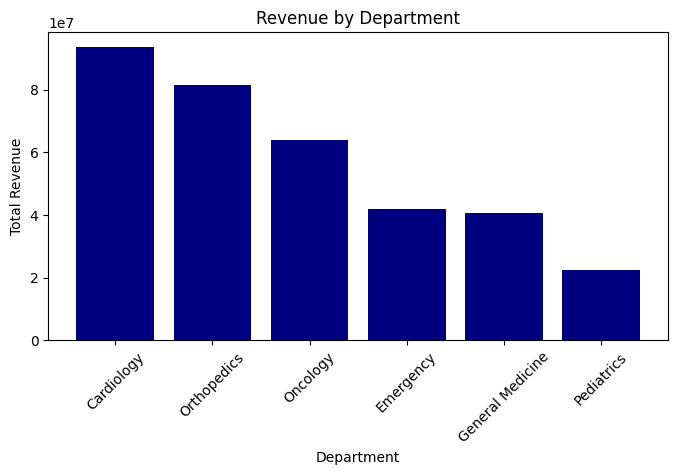

In [ ]:
#2.
dept_revenue = df.groupby('department')['billing_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(dept_revenue.index, dept_revenue.values, color='navy')
plt.xlabel('Department')
plt.ylabel('Total Revenue')
plt.title('Revenue by Department')
plt.xticks(rotation=45)
plt.show()

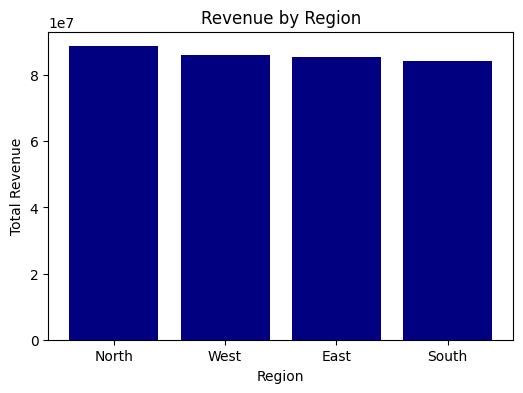

In [ ]:
#2.
region_revenue = df.groupby('region')['billing_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(region_revenue.index, region_revenue.values, color='navy')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.title('Revenue by Region')
plt.show()

Cardiology and Orthopedics generate the most revenue, while Pediatrics generates the least. Revenue is fairly even across all four regions.

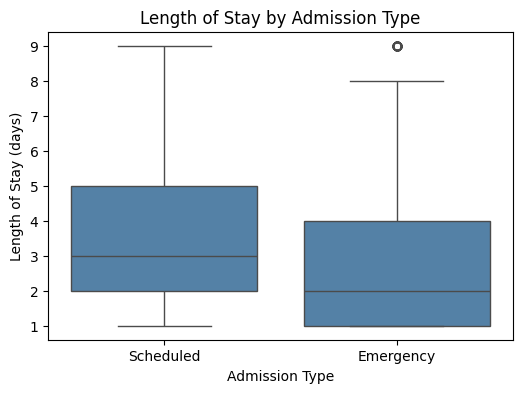

In [ ]:
#3.
plt.figure(figsize=(6, 4))
sns.boxplot(x='is_emergency', y='length_of_stay', data=df, color='steelblue')
plt.xlabel('Admission Type')
plt.ylabel('Length of Stay (days)')
plt.title('Length of Stay by Admission Type')
plt.show()

In [ ]:
#3.
emergency = df[df['is_emergency'] == 'Emergency']['length_of_stay']
scheduled = df[df['is_emergency'] == 'Scheduled']['length_of_stay']

shapiro_emergency = stats.shapiro(emergency.sample(min(len(emergency), 5000), random_state=1))
shapiro_scheduled = stats.shapiro(scheduled.sample(min(len(scheduled), 5000), random_state=1))
levene_test = stats.levene(emergency, scheduled)

Shapiro-Wilk Test (Emergency)
Statistic: 0.8391
p-value: 1.8980713363324784e-47

Shapiro-Wilk Test (Scheduled)
Statistic: 0.9003
p-value: 3.660293966851141e-49

Levene's Test
Statistic: 73.9756
p-value: 8.994657400721564e-18


In [ ]:
#3.
test_result = stats.mannwhitneyu(emergency, scheduled)

print()
print("Test Statistic:", test_result.statistic)
print("p-value:", test_result.pvalue)
print()
if test_result.pvalue < 0.05:
    print("Decision: Reject the Null Hypothesis.")
    print("Conclusion: There is a statistically significant difference in length of stay between Emergency and Scheduled admissions.")
else:
    print("Decision: Fail to Reject the Null Hypothesis.")
    print("Conclusion: There is no statistically significant difference in length of stay between Emergency and Scheduled admissions.")

Assumptions are not satisfied.
Using Mann-Whitney U Test.

Test Statistic: 9423035.5
p-value: 8.819449345355874e-53

Decision: Reject the Null Hypothesis.
Conclusion: There is a statistically significant difference in length of stay between Emergency and Scheduled admissions.


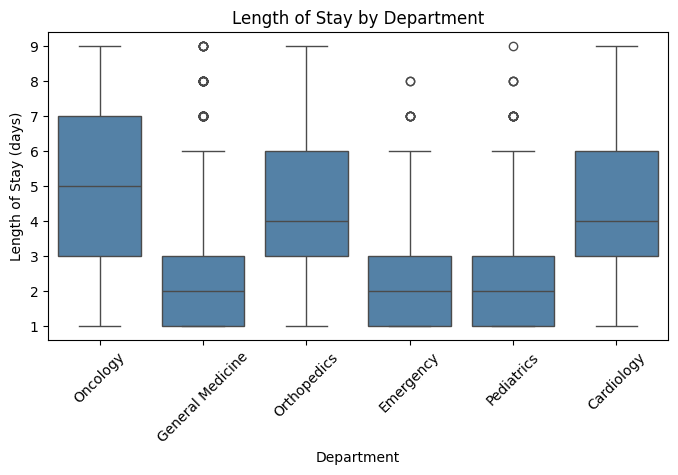

In [ ]:
#4.
plt.figure(figsize=(8, 4))
sns.boxplot(x='department', y='length_of_stay', data=df, color='steelblue')
plt.xlabel('Department')
plt.ylabel('Length of Stay (days)')
plt.title('Length of Stay by Department')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#4.
dept_groups = [g['length_of_stay'].values for _, g in df.groupby('department')]

normal_flags = []
for name, g in df.groupby('department'):
    sh = stats.shapiro(g['length_of_stay'].sample(min(len(g), 5000), random_state=1))
    normal_flags.append(sh.pvalue > 0.05)
    print(name, "- Statistic:", round(sh.statistic, 4), "p-value:", sh.pvalue)

levene_dept = stats.levene(*dept_groups)
print()
print("Levene's Test")
print("Statistic:", round(levene_dept.statistic, 4))
print("p-value:", levene_dept.pvalue)

Cardiology - Statistic: 0.9549 p-value: 1.8833610533232482e-23
Emergency - Statistic: 0.8396 p-value: 1.0053358875428089e-40
General Medicine - Statistic: 0.8671 p-value: 8.32948135656899e-42
Oncology - Statistic: 0.954 p-value: 3.0162446339686937e-16


Orthopedics - Statistic: 0.9446 p-value: 5.683764650430816e-26
Pediatrics - Statistic: 0.8247 p-value: 2.8580674612637686e-40

Levene's Test
Statistic: 274.6887
p-value: 1.6317631969495563e-277


In [ ]:
#4.
print("Assumptions are not satisfied.")
print("Using Kruskal-Wallis Test.")

test_result = stats.kruskal(*dept_groups)

print()
print("Test Statistic:", test_result.statistic)
print("p-value:", test_result.pvalue)
print()
if test_result.pvalue < 0.05:
    print("Decision: Reject the Null Hypothesis.")
    print("Conclusion: Average length of stay differs significantly across departments.")
else:
    print("Decision: Fail to Reject the Null Hypothesis.")
    print("Conclusion: Average length of stay does not differ significantly across departments.")

Assumptions are not satisfied.
Using Kruskal-Wallis Test.

Test Statistic: 3210.203617120972
p-value: 0.0

Decision: Reject the Null Hypothesis.
Conclusion: Average length of stay differs significantly across departments.


In [ ]:
#5.
readmit_table = pd.crosstab(df['department'], df['readmission'])
readmit_table

readmission,No,Yes
department,,
Cardiology,1441,407
Emergency,1658,314
General Medicine,2174,326
Oncology,700,207
Orthopedics,1620,256
Pediatrics,1555,214


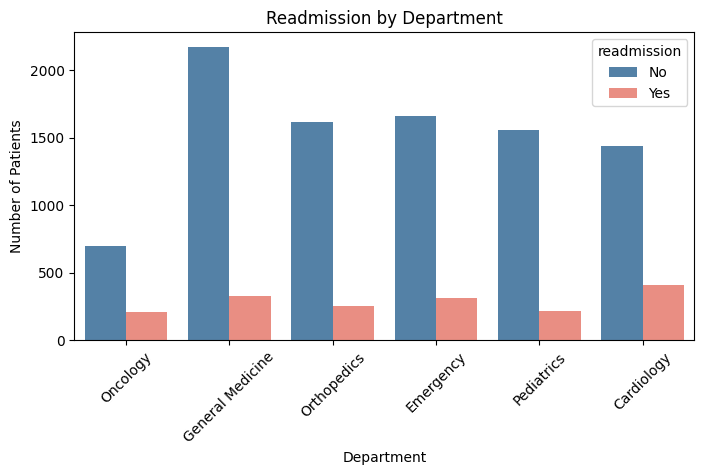

In [ ]:
#5.
plt.figure(figsize=(8, 4))
sns.countplot(x='department', hue='readmission', data=df, palette=['steelblue', 'salmon'])
plt.xlabel('Department')
plt.ylabel('Number of Patients')
plt.title('Readmission by Department')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#5.
chi2, p_value, dof, expected = stats.chi2_contingency(readmit_table)

print("Test Statistic:", chi2)
print("p-value:", p_value)
print()
if p_value < 0.05:
    print("Decision: Reject the Null Hypothesis.")
    print("Conclusion: There is a statistically significant association between department and readmission.")
else:
    print("Decision: Fail to Reject the Null Hypothesis.")
    print("Conclusion: There is no statistically significant association between department and readmission.")

Test Statistic: 126.1425504027267
p-value: 1.566359822542094e-25

Decision: Reject the Null Hypothesis.
Conclusion: There is a statistically significant association between department and readmission.


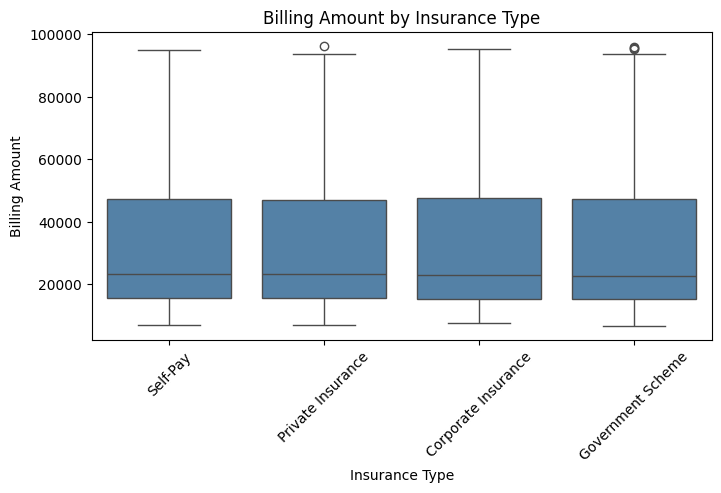

In [ ]:
#6.
plt.figure(figsize=(8, 4))
sns.boxplot(x='insurance_type', y='billing_amount', data=df, color='steelblue')
plt.xlabel('Insurance Type')
plt.ylabel('Billing Amount')
plt.title('Billing Amount by Insurance Type')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#6.
ins_groups = [g['billing_amount'].values for _, g in df.groupby('insurance_type')]

for name, g in df.groupby('insurance_type'):
    sh = stats.shapiro(g['billing_amount'].sample(min(len(g), 5000), random_state=1))
    print(name, "- Statistic:", round(sh.statistic, 4), "p-value:", sh.pvalue)

levene_ins = stats.levene(*ins_groups)

Corporate Insurance - Statistic: 0.8806 p-value: 4.811703776719471e-33
Government Scheme - Statistic: 0.8791 p-value: 1.0694990882335535e-46
Private Insurance - Statistic: 0.884 p-value: 4.751582918235903e-45
Self-Pay - Statistic: 0.8793 p-value: 1.3373108984250537e-38

Levene's Test
Statistic: 0.1893
p-value: 0.9037291886341413


In [ ]:
#6.
print("Assumptions are not satisfied.")
print("Using Kruskal-Wallis Test.")

test_result = stats.kruskal(*ins_groups)

print()
print("Test Statistic:", test_result.statistic)
print("p-value:", test_result.pvalue)
print()
if test_result.pvalue < 0.05:
    print("Decision: Reject the Null Hypothesis.")
    print("Conclusion: Billing amount differs significantly across insurance types.")
else:
    print("Decision: Fail to Reject the Null Hypothesis.")
    print("Conclusion: Billing amount does not differ significantly across insurance types.")

Assumptions are not satisfied.
Using Kruskal-Wallis Test.

Test Statistic: 1.3020603564593742
p-value: 0.7286438824316791

Decision: Fail to Reject the Null Hypothesis.
Conclusion: Billing amount does not differ significantly across insurance types.


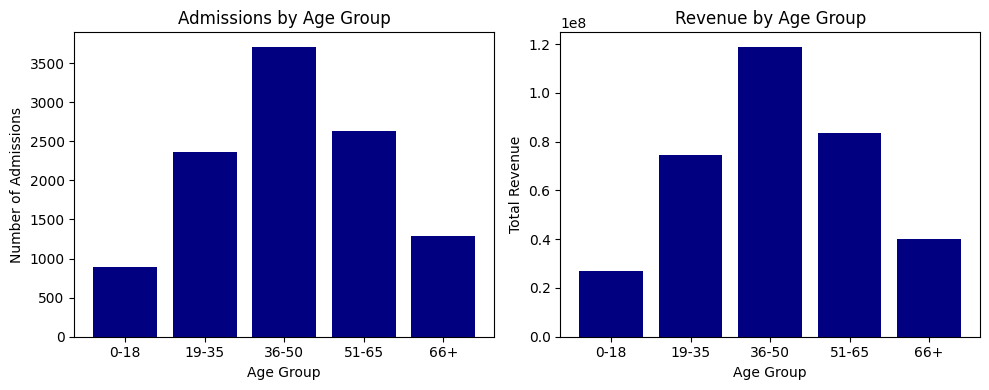

In [ ]:
#7.
age_group_counts = df['age_group'].value_counts().sort_index()
age_group_revenue = df.groupby('age_group')['billing_amount'].sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(age_group_counts.index.astype(str), age_group_counts.values, color='navy')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Admissions')
axes[0].set_title('Admissions by Age Group')

axes[1].bar(age_group_revenue.index.astype(str), age_group_revenue.values, color='navy')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Total Revenue')
axes[1].set_title('Revenue by Age Group')

plt.tight_layout()
plt.show()

In [ ]:
#7.
gender_counts = df['gender'].value_counts()
gender_revenue = df.groupby('gender')['billing_amount'].sum()

print("Admissions by gender:")
print(gender_counts)
print()
print("Revenue by gender:")
print(gender_revenue)

Admissions by gender:
gender
Male      5596
Female    5276
Name: count, dtype: int64

Revenue by gender:
gender
Female    1.685668e+08
Male      1.756441e+08
Name: billing_amount, dtype: float64


The 36-50 age group drives both the most admissions and the most revenue. Admissions and revenue are fairly balanced between male and female patients.

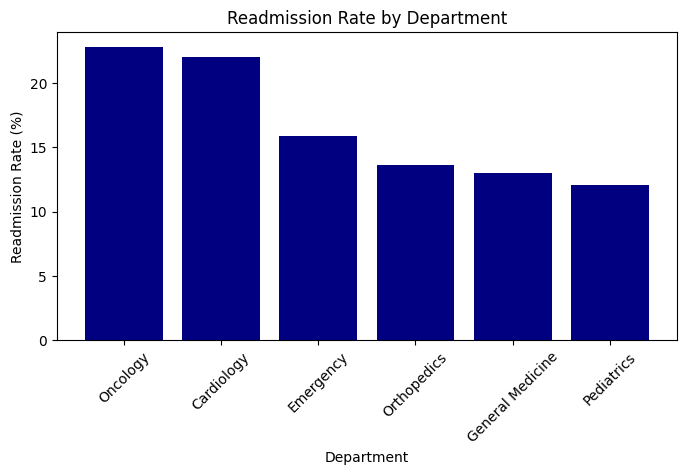

In [ ]:
#8.
readmission_rate = df.groupby('department')['readmission'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(readmission_rate.index, readmission_rate.values, color='navy')
plt.xlabel('Department')
plt.ylabel('Readmission Rate (%)')
plt.title('Readmission Rate by Department')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#8.
satisfaction_by_readmission = df.groupby('readmission')['satisfaction_score'].mean()
satisfaction_by_readmission

readmission
No     4.450262
Yes    3.509281
Name: satisfaction_score, dtype: float64

Oncology and Cardiology have the highest readmission rates. Patients who are readmitted report noticeably lower average satisfaction scores than those who are not.

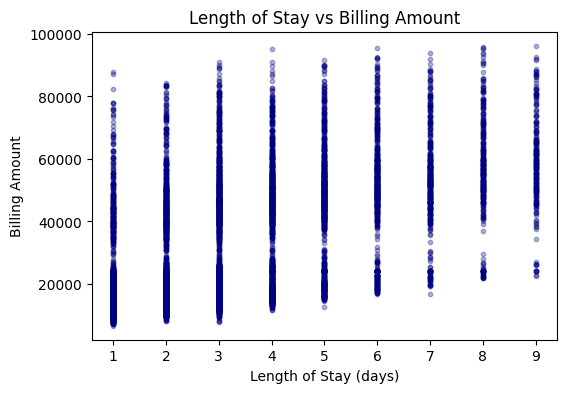

In [ ]:
#9.
plt.figure(figsize=(6, 4))
plt.scatter(df['length_of_stay'], df['billing_amount'], color='navy', alpha=0.3, s=10)
plt.xlabel('Length of Stay (days)')
plt.ylabel('Billing Amount')
plt.title('Length of Stay vs Billing Amount')
plt.show()

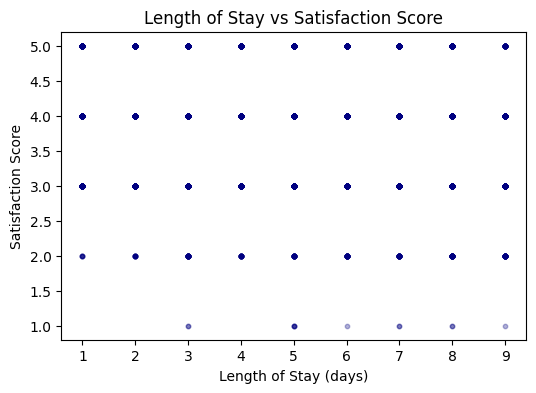

In [ ]:
#9.
plt.figure(figsize=(6, 4))
plt.scatter(df['length_of_stay'], df['satisfaction_score'], color='navy', alpha=0.3, s=10)
plt.xlabel('Length of Stay (days)')
plt.ylabel('Satisfaction Score')
plt.title('Length of Stay vs Satisfaction Score')
plt.show()

In [ ]:
#9.
shapiro_los = stats.shapiro(df['length_of_stay'].sample(5000, random_state=1))
shapiro_bill = stats.shapiro(df['billing_amount'].sample(5000, random_state=1))
shapiro_sat = stats.shapiro(df['satisfaction_score'].sample(5000, random_state=1))

print("Shapiro-Wilk Test (Length of Stay)")
print("Statistic:", round(shapiro_los.statistic, 4), "p-value:", shapiro_los.pvalue)
print()
print("Shapiro-Wilk Test (Billing Amount)")
print("Statistic:", round(shapiro_bill.statistic, 4), "p-value:", shapiro_bill.pvalue)
print()
print("Shapiro-Wilk Test (Satisfaction Score)")
print("Statistic:", round(shapiro_sat.statistic, 4), "p-value:", shapiro_sat.pvalue)

Shapiro-Wilk Test (Length of Stay)
Statistic: 0.887 p-value: 2.74323804506235e-51

Shapiro-Wilk Test (Billing Amount)
Statistic: 0.8839 p-value: 9.219470039910944e-52

Shapiro-Wilk Test (Satisfaction Score)
Statistic: 0.7856 p-value: 6.530832065293326e-63


In [ ]:
#9.
print("Assumptions are not satisfied.")
print("Using Spearman Correlation.")
print()

corr_bill = stats.spearmanr(df['length_of_stay'], df['billing_amount'])
print("Length of Stay vs Billing Amount")
print("Test Statistic:", corr_bill.correlation)
print("p-value:", corr_bill.pvalue)
if corr_bill.pvalue < 0.05:
    print("Decision: Reject the Null Hypothesis.")
    print("Conclusion: There is a statistically significant correlation between length of stay and billing amount.")
else:
    print("Decision: Fail to Reject the Null Hypothesis.")
    print("Conclusion: There is no statistically significant correlation between length of stay and billing amount.")

Assumptions are not satisfied.
Using Spearman Correlation.

Length of Stay vs Billing Amount
Test Statistic: 0.6062195028138527
p-value: 0.0
Decision: Reject the Null Hypothesis.
Conclusion: There is a statistically significant correlation between length of stay and billing amount.


In [46]:
#46.
corr_sat = stats.spearmanr(df['length_of_stay'], df['satisfaction_score'])
print("Length of Stay vs Satisfaction Score")
print("Test Statistic:", corr_sat.correlation)
print("p-value:", corr_sat.pvalue)
if corr_sat.pvalue < 0.05:
    print("Decision: Reject the Null Hypothesis.")
    print("Conclusion: There is a statistically significant correlation between length of stay and satisfaction score.")
else:
    print("Decision: Fail to Reject the Null Hypothesis.")
    print("Conclusion: There is no statistically significant correlation between length of stay and satisfaction score.")

Length of Stay vs Satisfaction Score
Test Statistic: -0.33686652529329103
p-value: 1.1111241549375677e-286
Decision: Reject the Null Hypothesis.
Conclusion: There is a statistically significant correlation between length of stay and satisfaction score.
